# 静的電場付与で得た寄与ベクトルを用いたイオン液体中のNaイオンの機械学習回帰モデル
寄与ベクトルを変えた場合の影響

In [1]:
import os  # for makedirs
import homcloud.interface as hc  # HomCloud 
import homcloud.paraview_interface as pv # HomCloud <-> paraview interface
import numpy as np  # Numerical array library
from tqdm import tqdm_notebook as tqdm  # For progressbar
import matplotlib.pyplot as plt  # Plotting
import sklearn.linear_model as lm  # Machine learning
from sklearn.decomposition import PCA  # for PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import pickle
from sklearn.svm import SVR
import scipy as sp

In /home/user/.local/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: 
The text.latex.preview rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
In /home/user/.local/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: 
The mathtext.fallback_to_cm rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
In /home/user/.local/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: Support for setting the 'mathtext.fallback_to_cm' rcParam is deprecated since 3.3 and will be removed two minor releases later; use 'mathtext.fallback : 'cm' instead.
In /home/user/.local/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: 
The validate_bool_maybe_none function was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
In /home/user/.local/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_c

In [34]:
pdvects = pd.DataFrame()
list_ = []
for i in range(0,500) :
    df = pd.read_table("/mnt/h/u-tokyo/pd_vector/p{:03d}.dat".format(i))
    df.columns=["{:03d}".format(i)]
    list_.append(df)
pdvects = pd.concat(list_,axis=1)
pdvects2 = pdvects.T
pdvects2

,0,1,2,3,4,5,6,7,8,9,...,2070,2071,2072,2073,2074,2075,2076,2077,2078,2079
000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
498,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [110]:
pdvects_all = np.array(pdvects2[1::5])
sc = StandardScaler()
pdvects_all2 = sc.fit_transform(pdvects_all)
pdvects_all2

array([[ 0.       ,  0.       ,  0.       , ...,  0.       , -0.1353881,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       , -0.1353881,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       , -0.1353881,
         0.       ],
       ...,
       [ 0.       ,  0.       ,  0.       , ...,  0.       , -0.1353881,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       , -0.1353881,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       , -0.1353881,
         0.       ]])

In [111]:
pd_vects_std = pdvects_all2 / pdvects_all2.max()
pd_vects_std

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.01360702,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.01360702,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.01360702,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.01360702,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.01360702,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.01360702,  0.        ]])

In [112]:
pca = PCA(n_components=100)
pca.fit(pd_vects_std)

PCA(n_components=100)

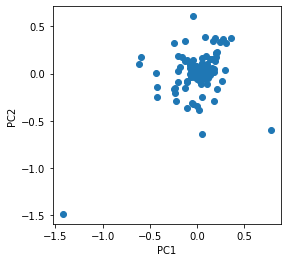

In [113]:
reduced = pca.transform(pd_vects_std)
plt.gca().set_aspect('equal') 

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.scatter(reduced[0],reduced[1])

In [79]:
pca.explained_variance_ratio_

array([1.23834731e-01, 3.44471131e-02, 3.29064811e-02, 3.15441111e-02,
       2.71824286e-02, 2.59126791e-02, 2.45310398e-02, 2.26080520e-02,
       2.11589757e-02, 2.08474570e-02, 2.00510430e-02, 1.99297040e-02,
       1.90657945e-02, 1.85684140e-02, 1.78340294e-02, 1.76832186e-02,
       1.71075750e-02, 1.64587975e-02, 1.58968832e-02, 1.48254918e-02,
       1.46115694e-02, 1.39037444e-02, 1.33776665e-02, 1.30424229e-02,
       1.22236989e-02, 1.21482899e-02, 1.19078598e-02, 1.18316639e-02,
       1.11995053e-02, 1.09395775e-02, 1.05618004e-02, 1.01454642e-02,
       9.73958074e-03, 9.39442850e-03, 9.25362801e-03, 9.19387296e-03,
       8.69679191e-03, 8.51640752e-03, 8.38387369e-03, 8.19847591e-03,
       8.11088620e-03, 7.98159160e-03, 7.66482784e-03, 7.53190956e-03,
       7.41770058e-03, 7.16404883e-03, 6.91380304e-03, 6.84953835e-03,
       6.75017138e-03, 6.55202658e-03, 6.53541882e-03, 6.30206323e-03,
       6.08271082e-03, 5.94686899e-03, 5.86420991e-03, 5.67251651e-03,
      

In [80]:
res = np.cumsum(pca.explained_variance_ratio_[:])
res

array([0.12383473, 0.15828184, 0.19118832, 0.22273244, 0.24991486,
       0.27582754, 0.30035858, 0.32296664, 0.34412561, 0.36497307,
       0.38502411, 0.40495382, 0.42401961, 0.44258802, 0.46042205,
       0.47810527, 0.49521285, 0.51167164, 0.52756853, 0.54239402,
       0.55700559, 0.57090933, 0.584287  , 0.59732942, 0.60955312,
       0.62170141, 0.63360927, 0.64544093, 0.65664044, 0.66758002,
       0.67814182, 0.68828728, 0.69802686, 0.70742129, 0.71667492,
       0.72586879, 0.73456558, 0.74308199, 0.75146587, 0.75966434,
       0.76777523, 0.77575682, 0.78342165, 0.79095356, 0.79837126,
       0.80553531, 0.81244911, 0.81929865, 0.82604882, 0.83260085,
       0.83913626, 0.84543833, 0.85152104, 0.85746791, 0.86333212,
       0.86900463, 0.87463827, 0.88018898, 0.88552123, 0.89078055,
       0.8957832 , 0.90066214, 0.90542241, 0.91014041, 0.91468065,
       0.91904236, 0.92321093, 0.92732158, 0.93130913, 0.93520926,
       0.93907743, 0.94281953, 0.94633081, 0.94968521, 0.95290

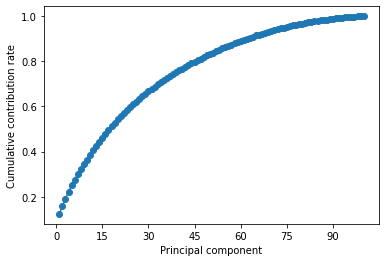

In [81]:
import matplotlib.ticker as ticker

plt.gca().get_xaxis().set_major_locator(ticker.MaxNLocator(integer=True))
plt.xlabel("Principal component")
plt.ylabel("Cumulative contribution rate")
#plt.scatter([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20], res)

plt.plot(np.arange(1,101),res)
plt.scatter(np.arange(1,101), res)

上記から100次元に削減しても0.9近い説明能力があることが分かった

比誘電率（目的変数，回帰学習）の読み込み

In [82]:
dc3__= pd.read_csv("../data/il_data_gra.csv", usecols =['Na+_diffusion'])
dc3__

,Na+_diffusion
0,220.844486
1,81.705898
2,-2.958248
3,40.425286
4,198.493303
...,...
495,7880.256389
496,2248.907990
497,-2776.158233
498,7649.944741


In [83]:
dc3__array=dc3__[1::5].values

In [114]:
dc3__std = dc3__array#/dc3__array.max()
dc3__std

array([[ 8.17058977e+01],
       [ 1.24460235e+02],
       [ 2.92036609e+01],
       [ 2.53781120e-01],
       [-2.03500136e+01],
       [ 3.21822555e+02],
       [ 9.21690118e+01],
       [-8.35762303e+00],
       [ 1.79333604e+01],
       [ 3.18434472e+01],
       [ 3.94364032e+01],
       [ 1.20812395e+02],
       [-1.20885758e+02],
       [-3.94081632e+01],
       [-3.42037672e+02],
       [ 1.28306560e+02],
       [-1.39427955e+01],
       [-3.35787436e+02],
       [ 1.71147282e+02],
       [-1.10572972e+01],
       [ 2.86004019e+01],
       [-1.73719071e+02],
       [-1.64174853e+02],
       [ 1.19843277e+02],
       [ 3.83313445e+01],
       [ 3.01876034e+02],
       [ 1.16704542e+02],
       [-5.22407786e+02],
       [ 6.83286114e+02],
       [ 5.07086659e+02],
       [ 1.77157553e+02],
       [ 2.25771060e+01],
       [-2.91981095e+02],
       [-2.44409651e+02],
       [ 3.39305097e+02],
       [ 1.38013337e+02],
       [ 6.46679420e+02],
       [ 8.30917354e+02],
       [ 4.2

In [115]:
reduced.shape

(100, 100)

In [116]:
y= dc3__std

In [117]:
X_train, X_test, y_train, y_test = train_test_split(reduced, y, test_size=0.3)

In [118]:
y_train

array([[ 9.21690118e+01],
       [ 6.83286114e+02],
       [ 1.36843278e+03],
       [ 1.20812395e+02],
       [-3.76333242e+01],
       [-7.51366297e+02],
       [ 5.54352289e+02],
       [-4.38606267e+02],
       [-1.48978047e+03],
       [ 1.16704542e+02],
       [-1.20885758e+02],
       [ 2.21663658e+02],
       [-5.22407786e+02],
       [ 3.01876034e+02],
       [ 3.80743903e+01],
       [ 5.07086659e+02],
       [-2.66067040e+01],
       [ 3.94364032e+01],
       [-1.39427955e+01],
       [-5.18839799e+03],
       [ 8.70569698e+02],
       [-8.35762303e+00],
       [-1.04830619e+03],
       [ 2.16289574e+02],
       [ 1.17254052e+02],
       [-1.10572972e+01],
       [ 1.79333604e+01],
       [ 1.28306560e+02],
       [ 9.04281305e+01],
       [ 2.93123795e+03],
       [-3.43276787e+01],
       [ 2.24890799e+03],
       [ 3.21822555e+02],
       [ 7.16490800e+02],
       [ 1.63474145e+02],
       [-7.07918535e+00],
       [ 8.30917354e+02],
       [ 2.92036609e+01],
       [ 1.6

In [119]:
X_train

array([[-2.15369684e-01, -1.88792426e-01, -5.67113256e-03, ...,
         2.01925848e-02,  3.68665105e-02,  1.90277481e-16],
       [ 1.99389050e-01, -6.69798846e-02, -5.13575590e-02, ...,
         2.16822633e-03, -7.43001473e-03,  6.30029882e-16],
       [ 4.68830900e-01,  6.50071485e-01, -2.21943701e-02, ...,
        -2.76256598e-03, -4.03695817e-03,  1.89626960e-16],
       ...,
       [-8.87679611e-01, -1.72521421e-01, -3.08573494e-02, ...,
        -8.59741412e-02, -3.29728910e-02, -4.01154804e-18],
       [ 2.43466014e-01, -3.87248791e-01, -7.99686195e-02, ...,
         3.66068433e-02, -3.22428310e-02,  7.97430698e-16],
       [-8.85053121e-01,  1.29686643e-01,  4.55175931e-02, ...,
         1.75388958e-02,  2.96885010e-02,  2.07624716e-16]])

In [120]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(X_train)
X_train2 = ss.transform(X_train)

ss.fit(X_test)
X_test2 = ss.transform(X_test)


SVRによる機械学習

In [48]:
#Random search
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from sklearn.metrics import (roc_curve, auc, accuracy_score)
from sklearn.ensemble import RandomForestRegressor

#param_dist = {"max_depth": [3, None],                  #distribution
#              "n_estimators":[50,100,200,300,400,500],

param_dist = {"max_depth": [i for i in range(1,100,1)],                  #distribution
              "n_estimators":[i for i in range(10,1000,10)],
              "max_features": sp_randint(1, 100),
              "min_samples_split": sp_randint(2, 30),
              "min_samples_leaf": sp_randint(1, 30),
#              "bootstrap": [True, False],
#              "criterion": ["gini", "entropy"],
             }

forest_random = RandomizedSearchCV( estimator=RandomForestRegressor(random_state=None),
                                    param_distributions=param_dist,
                                    cv=3,              #CV
                                    n_iter=1000,          #interation num
#                                    scoring="accuracy", #metrics
                                    n_jobs=-1,           #num of core
                                    verbose=1,          
                                    random_state=1)

forest_random.fit(X_train,y_train)
forest_random_best = forest_random.best_estimator_ #best estimator
print("Best Model Parameter: ",forest_random.best_params_)
pred = forest_random.predict(X_test)
print(forest_random.score(X_test,y_test))
print(forest_random.score(X_train,y_train))

Fitting 3 folds for each of 1000 candidates, totalling 3000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:  7.5min
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed: 10.4min
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed: 13.9min
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed: 16.7min finished
/home/user/.local/lib/python3.6/site-packages/sklearn/model_selection/_search.py:765: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)


Best Model Parameter:  {'max_depth': 28, 'max_features': 1, 'min_samples_leaf': 27, 'min_samples_split': 20, 'n_estimators': 210}
-0.005206663860818139
0.0635608455707033


NameError: name 'train' is not defined

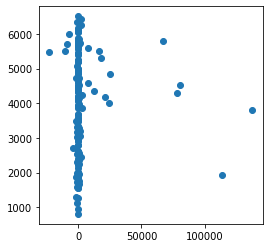

In [49]:
fig = plt.figure(figsize=(4,4), dpi=72, facecolor="w")

x0 = 0.9
y0 = 0.9
x10 = 1.6
y10 = 1.6

ax = fig.add_subplot(111)
ax.scatter(y_test, pred, label="test", marker="o")# c="blue", alpha=0.7, linewidth="1", label="test")
ax.scatter(y_train, train, label="train", marker="^")#, c="red", alpha=0.7, linewidth="1", label="train")
ax.plot((x0,x10),(y0,y10))
ax.set_xlabel("Calculation of ")
ax.set_ylabel("Prediction of ")
#ax.set_xlim(1,1.6)
#ax.set_ylim(1,1.6)
ax.legend()

In [27]:
reduced

(228, 100)

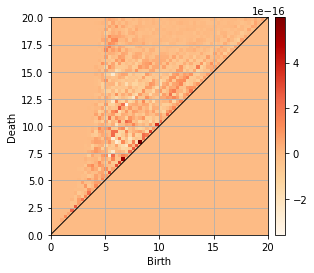

In [30]:
mesh = hc.PIVectorizerMesh((0, 20), 64, sigma=0.02, weight=("atan", 0.01, 3))
mesh.histogram_from_vector(pca.mean_).plot()

In [32]:
coef = pca.components_[0, :].ravel()
pdextract = mesh.mask_from_vector(coef > 0.02)

In [33]:
pdlist_ = hc.PDList("/mnt/h/data/20200824_1/pd/p000.idiagram")
pd_ = pdlist_.dth_diagram(2)
pdextract_pairs = pdextract.filter_pd(pd_)
pdextract_pairs

[Pair(2.433332637388363, 2.812791368101944),
 Pair(2.4597920933703774, 2.8130105381948507),
 Pair(2.4258650547866822, 2.813033439659479),
 Pair(2.4248948242585717, 2.8135439740335118),
 Pair(2.3243151165234193, 2.813583596450632),
 Pair(2.3668761547617243, 2.8139383571207537),
 Pair(2.4197093431955743, 2.8139786824556126),
 Pair(2.4673273190708347, 2.8144702540920483),
 Pair(2.4327329576319756, 2.8148772068476817),
 Pair(2.4700937879471576, 2.814999418084362),
 Pair(2.491413544681305, 2.8151548277015763),
 Pair(2.4804624322552025, 2.815199219171761),
 Pair(2.490013487822342, 2.81526635373156),
 Pair(2.4534669197664827, 2.8158162564075004),
 Pair(2.4635924482484324, 2.8168091159431046),
 Pair(2.429713951245181, 2.8168106621615925),
 Pair(2.4660542519086586, 2.816818810112277),
 Pair(2.387710459409592, 2.8170122390197383),
 Pair(2.4617774655485247, 2.8175896482485494),
 Pair(2.4605433505411596, 2.817610004444548),
 Pair(2.44090596351005, 2.817897584652935),
 Pair(2.4529324964582977, 2.81

In [35]:
len(pdextract_pairs)

6462

In [36]:
#1%を表示することにする
pdextract_pairs_random = np.random.choice(pdextract_pairs, 64, replace=False)
pdextract_pairs_random

array([Pair(8.664429305647314, 9.442281760051076),
       Pair(10.28687997782842, 10.368247451906813),
       Pair(10.22180341511658, 10.937881406725348),
       Pair(5.9831503878525085, 12.431619124518573),
       Pair(9.99870839421347, 10.007744190670897),
       Pair(9.357886280438384, 9.385445594983127),
       Pair(8.525610160227908, 10.951637198782235),
       Pair(8.521560439535303, 8.88377617047118),
       Pair(6.46885724251764, 12.73811635738095),
       Pair(8.524545452471417, 8.799036991027757),
       Pair(2.4926552190359144, 2.854160497322208),
       Pair(8.54716999041372, 8.762847990654965),
       Pair(10.894944626729483, 10.943052010486637),
       Pair(7.063570190656088, 9.834340507536414),
       Pair(9.00979569594742, 9.111001191834962),
       Pair(8.881932458620733, 9.38751274707836),
       Pair(2.4972938391743327, 2.8467392935702116),
       Pair(8.760341526516445, 11.272663501078583),
       Pair(10.099381824203991, 12.089976533434786),
       Pair(7.802144579

In [37]:
optimal_volume_pdextract = [pair.optimal_volume() for pair in pdextract_pairs_random]

In [39]:
pv.show([
    hc.OptimalVolume.to_paraview_node_for_volumes(
        optimal_volume_pdextract,
        gui_name="Optimal volume: blue 0"
    ).threshold("isboundary", 1).set_color((0, 0, 1)).set_linewidth(1),
    pv.PointCloud("/mnt/h/data/20200824_1/homcloud_p000_out.txt", dim=3, delimiters=" "),
], wait=False)

In [25]:
reg.score(X_test,y_test)

NameError: name 'reg' is not defined

In [72]:
reg.score(X_train,y_train)

0.17736199885649861

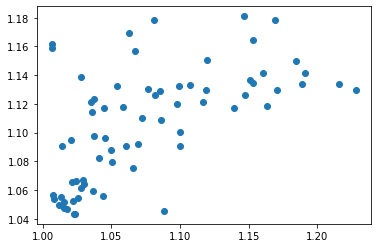

In [73]:
pred2 = reg.predict(X_test)

plt.scatter(y_test, pred2)
plt.show()

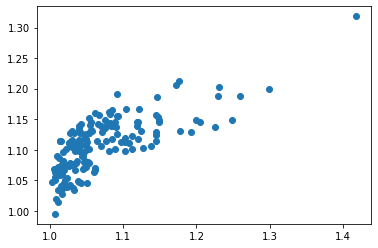

In [74]:
train2 = reg.predict(X_train)

plt.scatter(y_train, train2)
plt.show()

In [75]:
fig = plt.figure(figsize=(4,4), dpi=72, facecolor="w")

x0 = 1
y0 = 1
x10 = 1.6
y10 = 1.6

ax = fig.add_subplot(111)
ax.scatter(y_test, pred2, c="blue", alpha=0.7, linewidth="1", label="test")
ax.scatter(y_train, train2, c="red", alpha=0.7, linewidth="1", label="train")
ax.plot((x0,x10),(y0,y10))
ax.set_xlabel("Calculation")
ax.set_ylabel("Prediction")
ax.set_xlim(1,1.6)
ax.set_ylim(1,1.6)
plt.legend()
plt.show()


TypeError: must be real number, not str

<Figure size 288x288 with 1 Axes>

NNによる機械学習

In [66]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPRegressor

param_dist = {'batch_size': [300, 350, 400, 450],
#               'hidden_layer_sizes': [(150, 150), (100, 100, 50), (150, 100, 50), (200, 200, 200)],
              'hidden_layer_sizes': [(500, 500, 500), (1000, 1000, 1000), (2000, 2000, 2000), (200, 200, 200)],
              'max_iter': [400, 500, 600, 700, 800],
               'random_state': [0]}

#{"hidden_layer_sizes":[(i for i in range(100,1000,10), i for i in range(100,1000,10)),],
#             "max_iter": [7000],
#              "alpha" : [0.0001, 0,001, 0.01], 
#            }

reg2 = RandomizedSearchCV( estimator=MLPRegressor(),
                                     param_distributions=param_dist,
                                     cv=5,
                                     n_iter=2000,
                                     n_jobs=-1,
                                     verbose=1,
#                                     random_state=1
                         )

reg2.fit(X_train2, y_train)
reg_best2 = reg2.best_estimator_
print("Best Model Parameter:", reg2.best_params_)
print(reg2.score(X_test,y_test))

/home/user/.local/lib/python3.6/site-packages/sklearn/model_selection/_search.py:282: UserWarning: The total space of parameters 80 is smaller than n_iter=2000. Running 80 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


Fitting 5 folds for each of 80 candidates, totalling 400 fits


[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   39.5s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed: 10.6min
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed: 22.0min finished
/home/user/.local/lib/python3.6/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


Best Model Parameter: {'random_state': 0, 'max_iter': 400, 'hidden_layer_sizes': (1000, 1000, 1000), 'batch_size': 300}
-0.08863661658499855


In [67]:
reg2.score(X_train2,y_train)

0.7116445395990623

In [68]:
reg2.score(X_test2,y_test)

-0.214661565629642

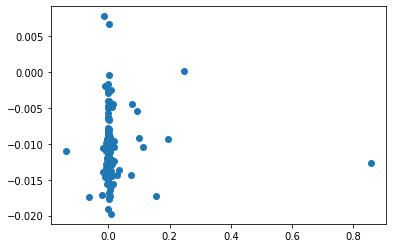

In [69]:
pred3 = reg2.predict(X_test)

plt.scatter(y_test, pred3)
plt.show()

In [70]:
train3 = reg2.predict(X_train)


No handles with labels found to put in legend.


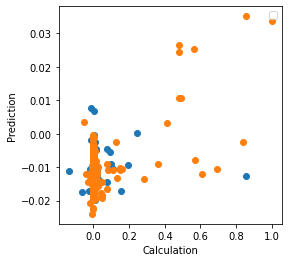

In [74]:
fig = plt.figure(figsize=(4,4), dpi=72, facecolor="w")

#x0 = 1
#y0 = 1
#x10 = 1.6
#y10 = 1.6

ax = fig.add_subplot(111)
ax.scatter(y_test, pred3)#, c="blue", alpha=0.7, linewidth="1", label="test")
ax.scatter(y_train, train3)#, c="red", alpha=0.7, linewidth="1", label="train")
#ax.plot((x0,x10),(y0,y10))
ax.set_xlabel("Calculation")
ax.set_ylabel("Prediction")
#ax.set_xlim(1,1.6)
#ax.set_ylim(1,1.6)
plt.legend()
plt.show()

ランダムフォレストモデルによる機械学習

In [121]:
#Random search
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from sklearn.metrics import (roc_curve, auc, accuracy_score)
from sklearn.ensemble import RandomForestRegressor

#param_dist = {"max_depth": [3, None],                  #distribution
#              "n_estimators":[50,100,200,300,400,500],

param_dist = {"max_depth": [i for i in range(1,100,1)],                  #distribution
              "n_estimators":[i for i in range(10,100,10)],
              "max_features": sp_randint(1, 20),
              "min_samples_split": sp_randint(2, 20),
              "min_samples_leaf": sp_randint(1, 20),
#              "bootstrap": [True, False],
#              "criterion": ["gini", "entropy"],
             }

forest_random = RandomizedSearchCV( estimator=RandomForestRegressor(random_state=None),
                                    param_distributions=param_dist,
                                    cv=5,              #CV
                                    n_iter=1000,          #interation num
#                                    scoring="accuracy", #metrics
                                    n_jobs=-1,           #num of core
                                    verbose=1,          
                                    random_state=1)

forest_random.fit(X_train,y_train)
forest_random_best = forest_random.best_estimator_ #best estimator
print("Best Model Parameter: ",forest_random.best_params_)

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 828 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 1528 tasks      | elapsed:   17.3s
[Parallel(n_jobs=-1)]: Done 2428 tasks      | elapsed:   27.6s
[Parallel(n_jobs=-1)]: Done 3528 tasks      | elapsed:   39.4s
[Parallel(n_jobs=-1)]: Done 4828 tasks      | elapsed:   53.7s


Best Model Parameter:  {'max_depth': 80, 'max_features': 8, 'min_samples_leaf': 10, 'min_samples_split': 13, 'n_estimators': 20}


[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   55.6s finished
/home/user/.local/lib/python3.6/site-packages/sklearn/model_selection/_search.py:765: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)


In [122]:
pred = forest_random.predict(X_test)
forest_random.score(X_test,y_test)

-0.09545800695086104

In [123]:
forest_random.score(X_train,y_train)

0.1396587451594168

In [124]:
pred

array([147.27127883, 149.29454206, 221.34970628, 236.48035206,
       294.47264846, 362.19839889,  73.77051891, 460.894922  ,
        30.15401414,  58.00425852, 530.86889585, 122.90532194,
       160.72352872, 369.91557547,  71.92764571,   9.96247858,
       283.20987354, 351.93472749, 318.86169555,  49.99260837,
       215.56423496, 347.01322822, 408.55109059, 266.88324091,
       125.30186851, 130.41054016, 151.8778559 , 333.31670992,
       214.29149119,  71.73158001])

In [125]:
y_test

array([[ 3.18434472e+01],
       [-1.49312291e+02],
       [ 1.24460235e+02],
       [-2.25302128e+04],
       [-3.32600879e+01],
       [-2.93528851e+01],
       [ 1.77157553e+02],
       [ 3.46509639e+01],
       [-1.73719071e+02],
       [ 5.49689183e+02],
       [ 1.25523268e+04],
       [ 2.43178754e+04],
       [-3.90480903e+02],
       [ 6.73452211e+04],
       [-3.42037672e+02],
       [ 1.19843277e+02],
       [-1.95486909e+01],
       [ 1.56115891e+03],
       [ 4.26349843e+02],
       [ 9.30364121e+04],
       [ 3.18236283e+04],
       [-9.33339627e+02],
       [-3.70104456e+03],
       [ 2.14078744e+03],
       [ 2.53781120e-01],
       [ 6.46679420e+02],
       [-2.44409651e+02],
       [ 8.83986790e+01],
       [-1.26922840e+01],
       [ 3.83313445e+01]])

In [126]:
train = forest_random.predict(X_train)

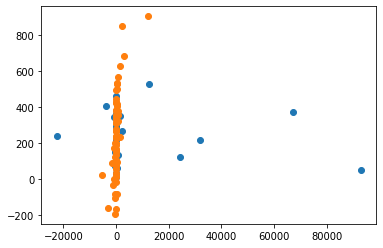

In [127]:
plt.scatter(y_test, pred)
plt.scatter(y_train, train)
plt.show()

In [58]:
train =forest_random.predict(X_train)

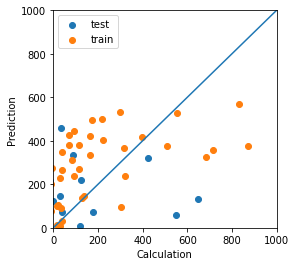

In [131]:
fig = plt.figure(figsize=(4,4), dpi=72, facecolor="w")

x0 = 0
y0 = 0
x10 = 1000
y10 = 1000

ax = fig.add_subplot(111)
ax.scatter(y_test, pred, label="test")
ax.scatter(y_train, train, label="train")
ax.plot((x0,x10),(y0,y10))
ax.set_xlabel("Calculation")
ax.set_ylabel("Prediction")
ax.set_xlim(0,1000)
ax.set_ylim(0,1000)
plt.legend()
plt.show()

In [46]:
#Random search　繰り返し
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from sklearn.metrics import (roc_curve, auc, accuracy_score)
from sklearn.ensemble import RandomForestRegressor



#param_dist = {"max_depth": [3, None],                  #distribution
#              "n_estimators":[50,100,200,300,400,500],

for k in range(100):

    param_dist = {"max_depth": [i for i in range(1,40,1)],                  #distribution
              "n_estimators":[i for i in range(10,100,10)],
              "max_features": sp_randint(1, 50),
              "min_samples_split": sp_randint(2, 11),
              "min_samples_leaf": sp_randint(1, 11),
#              "bootstrap": [True, False],
#              "criterion": ["gini", "entropy"],
             }

    forest_random = RandomizedSearchCV( estimator=RandomForestRegressor(random_state=None),
                                    param_distributions=param_dist,
                                    cv=5,              #CV
                                    n_iter=500,          #interation num
#                                    scoring="accuracy", #metrics
                                    n_jobs=-1,           #num of core
                                    verbose=1,          
                                    random_state=0)

    forest_random.fit(X_train,y_train)
    forest_random_best = forest_random.best_estimator_ #best estimator
    pred = forest_random.predict(X_test)
    with open("rm_20201112.txt", "a") as f1:
        print("Best Model Parameter: ",forest_random.best_params_, file=f1)
        print("Train_score",forest_random.score(X_train,y_train), file=f1)
        print("Test_score:",pred, file=f1)
    features = pd.DataFrame(X_train).columns
    importances = forest_random_best.feature_importances_
    indices = np.argsort(importances)[::-1]
    importances2 = np.sort(importances)[::-1][0:50]

    indices2 = indices[0:50]
    rm_counts = np.count_nonzero(importances2)
    rm_extract = indices2[:rm_counts:]
    with open("pd_importances_20201218.txt", "a") as f2:    
        print("vector:",rm_extract, file=f2)
        print("importances:",importances2, file=f2)
    with open("pd_importances_vector_20201218.txt", "a") as f2:    
        print("vector:",rm_extract, file=f2)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 828 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 1528 tasks      | elapsed:   18.1s
[Parallel(n_jobs=-1)]: Done 2428 tasks      | elapsed:   28.1s
[Parallel(n_jobs=-1)]: Done 2500 out of 2500 | elapsed:   29.0s finished


Fitting 5 folds for each of 500 candidates, totalling 2500 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 828 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 1528 tasks      | elapsed:   17.8s
[Parallel(n_jobs=-1)]: Done 2428 tasks      | elapsed:   27.8s
[Parallel(n_jobs=-1)]: Done 2500 out of 2500 | elapsed:   28.8s finished


Fitting 5 folds for each of 500 candidates, totalling 2500 fits


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 828 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 1528 tasks      | elapsed:   17.7s
[Parallel(n_jobs=-1)]: Done 2428 tasks      | elapsed:   27.7s
[Parallel(n_jobs=-1)]: Done 2500 out of 2500 | elapsed:   28.7s finished


Fitting 5 folds for each of 500 candidates, totalling 2500 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 828 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 1528 tasks      | elapsed:   17.7s
[Parallel(n_jobs=-1)]: Done 2428 tasks      | elapsed:   27.6s
[Parallel(n_jobs=-1)]: Done 2500 out of 2500 | elapsed:   28.6s finished


Fitting 5 folds for each of 500 candidates, totalling 2500 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 828 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 1528 tasks      | elapsed:   17.7s
[Parallel(n_jobs=-1)]: Done 2428 tasks      | elapsed:   27.6s
[Parallel(n_jobs=-1)]: Done 2500 out of 2500 | elapsed:   28.6s finished


IndexError: too many indices for array

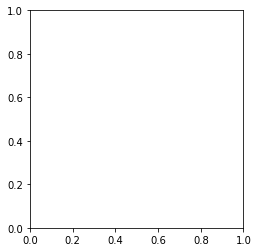

In [42]:
fig = plt.figure(figsize=(13,4), dpi=72,facecolor="w")

x0_0 = 1
y0_0 = 1
x10_0 = 1.6
y10_0 = 1.6

ax1 = fig.add_subplot(131)
ax1.scatter(y_test[:,2], pred[:,2], c="blue", alpha=0.7, linewidth="1", label="test")
ax1.scatter(y_train[:,2], train[:,2], c="red", alpha=0.7, linewidth="1", label="train")
ax1.plot((x0_0,x10_0),(y0_0,y10_0))
ax1.set_xlabel("Calculation of Dielectric Contant (-)")
ax1.set_ylabel("Prediction of Dielectric Constan (-)")
ax1.set_xlim(1.42,1.48)
ax1.set_ylim(1.42,1.48)

plt.legend()

x0_1 = 0
y0_1 = 0
x10_1 = 1000
y10_1 = 1000

ax2 = fig.add_subplot(132)
ax2.scatter(y_test[:,0], pred[:,0], c="blue", alpha=0.7, linewidth="1", label="test")
ax2.scatter(y_train[:,0], train[:,0], c="red", alpha=0.7, linewidth="1", label="train")
ax2.plot((x0_1,x10_1),(y0_1,y10_1))
ax2.set_xlabel("Calculation of Temparature (K)")
ax2.set_ylabel("Prediction of Temparature (K)")
ax2.set_xlim(200, 900)
ax2.set_ylim(200, 900)

x0_2 = 0
y0_2 = 0
x10_2 = 2000
y10_2 = 2000

ax3 = fig.add_subplot(133)
ax3.scatter(y_test[:,1], pred[:,1], c="blue", alpha=0.7, linewidth="1", label="test")
ax3.scatter(y_train[:,1], train[:,1], c="red", alpha=0.7, linewidth="1", label="train")
ax3.plot((x0_2,x10_2),(y0_2,y10_2))
ax3.set_xlabel("Calculation of Pressure (atm)")
ax3.set_ylabel("Prediction of Pressure (atm)")
ax3.set_xlim(0,2000)
ax3.set_ylim(0,2000)


fig.tight_layout()

plt.savefig("../results/ML.png")

plt.show()

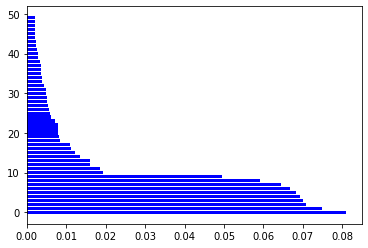

In [31]:
features = pd.DataFrame(X_train).columns
importances = forest_random_best.feature_importances_
indices = np.argsort(importances)[::-1]

importances2 = np.sort(importances)[::-1][0:50]
indices2 = indices[0:50]

#plt.figure(figsize=(100,100))
plt.barh(range(len(indices2)), importances2, color='b', align='center')
#plt.yticks(range(len(indices)), features[indices])
plt.show()

In [32]:
importances2

array([1.92444416e-01, 9.92261626e-02, 9.79917953e-02, 9.67640779e-02,
       9.63639755e-02, 9.60683993e-02, 9.27954205e-02, 9.10199098e-02,
       8.73525089e-02, 1.17234427e-02, 7.30375960e-03, 6.14916996e-03,
       4.97936117e-03, 3.13031483e-03, 2.39623602e-03, 2.25186989e-03,
       2.22884635e-03, 1.46332034e-03, 1.40425427e-03, 6.91826145e-04,
       6.66649680e-04, 6.51115010e-04, 4.56266442e-04, 4.25382349e-04,
       3.86880495e-04, 3.57298596e-04, 3.57296658e-04, 3.45365775e-04,
       3.36807331e-04, 3.29578216e-04, 3.27016424e-04, 2.85309131e-04,
       2.34315607e-04, 2.13434418e-04, 2.13010229e-04, 1.62356359e-04,
       1.53300333e-04, 1.18829199e-04, 1.08904936e-04, 6.82136843e-05,
       2.12101162e-05, 2.03628352e-05, 1.20286349e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00])

In [32]:
rm_counts = np.count_nonzero(importances2)
rm_counts

50

In [33]:
indices2

array([ 148,  494,  457,  488,  290, 1033,  242,  117,  316,  376,  186,
        103,  721, 1429, 1032,  462,  314,  662, 1100, 1028,  226,  206,
        208,  800, 1007,  549,  400,  229,  227, 1342, 1615,  646,   26,
        348,  923,  296, 1011,  431,   53,   64,  656,  888,  986,  167,
       1004,  116,  455, 1073, 1192,  579])

In [34]:
rm_extract = indices2[:rm_counts:]
rm_extract

array([ 148,  494,  457,  488,  290, 1033,  242,  117,  316,  376,  186,
        103,  721, 1429, 1032,  462,  314,  662, 1100, 1028,  226,  206,
        208,  800, 1007,  549,  400,  229,  227, 1342, 1615,  646,   26,
        348,  923,  296, 1011,  431,   53,   64,  656,  888,  986,  167,
       1004,  116,  455, 1073, 1192,  579])

In [35]:
len(rm_extract)

50

In [36]:
np.ravel(rm_extract)

array([ 148,  494,  457,  488,  290, 1033,  242,  117,  316,  376,  186,
        103,  721, 1429, 1032,  462,  314,  662, 1100, 1028,  226,  206,
        208,  800, 1007,  549,  400,  229,  227, 1342, 1615,  646,   26,
        348,  923,  296, 1011,  431,   53,   64,  656,  888,  986,  167,
       1004,  116,  455, 1073, 1192,  579])

In [38]:
#pdvects_extract_ = pdvects2.iloc[:,rm_extract]
#pdvects_extract_ = pdvects2.iloc[:,[88,266]]
pdvects_extract_ = pdvects2.iloc[:,[203]]
pdvects_extract_

,203
000,17.245558
001,23.827833
002,23.498719
003,23.827833
004,27.316438
...,...
056,50.749334
057,48.906297
058,46.997438
059,47.984779


In [37]:
pdvects_extract = np.array(pdvects_extract_)
sc = StandardScaler()
pdvects_extract2 = sc.fit_transform(pdvects_extract)
pdvects_extract2

NameError: name 'pdvects_extract_' is not defined

In [40]:
import GPy
from sklearn.datasets import make_friedman2
from pmlearn.gaussian_process import GaussianProcessRegressor
from pmlearn.gaussian_process.kernels import DotProduct, WhiteKernel

WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [30]:
import GPy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

kernel = GPy.kern.RBF(input_dim=1, variance=0.01, lengthscale=0.2)
#kernel = GPy.kern.RBF(1) + GPy.kern.Bias(1) + GPy.kern.Linear(1)

d_ = np.loadtxt("/mnt/h/data/20200824_1/DC_result.dat", skiprows = 1)
d = pd.DataFrame(d_)
d.columns = ['Y','X','X2']
model = GPy.models.GPRegression(X_,y_, kernel=kernel)
model.optimize()
model.plot()
plt.show()

## prediction
x_pred = np.linspace(300, 800, 100)
x_pred = x_pred[:, None]
y_qua_pred = model.predict_quantiles(x_pred, quantiles=(2.5, 50, 97.5))[0]

ValueError: Length mismatch: Expected axis has 4 elements, new values have 3 elements

In [18]:
X_ = np.array(pdvects_extract2)
X_

NameError: name 'pdvects_extract2' is not defined

In [45]:
pdvects_extract2_ = pdvects2.iloc[:,[148,494]]
X2_ = np.array(pdvects_extract2_)
X2_

array([[ 8.69030133,  0.13488769],
       [11.24856982,  0.15594482],
       [12.24453693,  0.15625   ],
       [12.98663008,  0.15075683],
       [13.61155063,  0.15686035],
       [14.37317254,  0.14923095],
       [15.33008213,  0.14587402],
       [16.48227938,  0.14465332],
       [15.97453144,  0.13458252],
       [16.69709582,  0.15502929],
       [16.34557801,  0.14373779],
       [10.56506297,  0.14099121],
       [ 9.80344105,  0.13885498],
       [ 9.58862462,  0.14678955],
       [10.95563831,  0.14312744],
       [11.44385749,  0.14923095],
       [10.29166023,  0.14770507],
       [11.20951228,  0.15014648],
       [11.48291502,  0.15411376],
       [36.69455327,  0.25634765],
       [35.09319437,  0.27343749],
       [32.18340808,  0.35034179],
       [34.99555054,  0.27648925],
       [34.93696424,  0.27130126],
       [35.26895328,  0.27465819],
       [34.44874506,  0.26763915],
       [36.20633409,  0.26977538],
       [34.46827383,  0.2581787 ],
       [31.03121083,

In [46]:
X2_2 = np.array(X2_)
sc = StandardScaler()
X2_3 = sc.fit_transform(X2_2)
X2_3

array([[-1.66602449e+00, -1.92659928e+00],
       [-1.40686612e+00, -1.61010348e+00],
       [-1.30597240e+00, -1.60551658e+00],
       [-1.23079668e+00, -1.68808070e+00],
       [-1.16749082e+00, -1.59634279e+00],
       [-1.09033680e+00, -1.71101518e+00],
       [-9.93399696e-01, -1.76147103e+00],
       [-8.76679510e-01, -1.77981862e+00],
       [-9.28115524e-01, -1.93118618e+00],
       [-8.54918120e-01, -1.62386416e+00],
       [-8.90527668e-01, -1.79357930e+00],
       [-1.47610690e+00, -1.83486137e+00],
       [-1.55326092e+00, -1.86696964e+00],
       [-1.57502231e+00, -1.74771035e+00],
       [-1.43654074e+00, -1.80275310e+00],
       [-1.38708303e+00, -1.71101518e+00],
       [-1.50380322e+00, -1.73394966e+00],
       [-1.41082273e+00, -1.69725449e+00],
       [-1.38312642e+00, -1.63762485e+00],
       [ 1.17086950e+00, -1.01014782e-01],
       [ 1.00864823e+00,  1.55851378e-01],
       [ 7.13880303e-01,  1.31174910e+00],
       [ 9.98756688e-01,  2.01720336e-01],
       [ 9.

 /home/user/.local/lib/python3.6/site-packages/GPy/plotting/matplot_dep/plot_definitions.py:184: UserWarning:The following kwargs were not used by contour: 'label', 'linewidth'


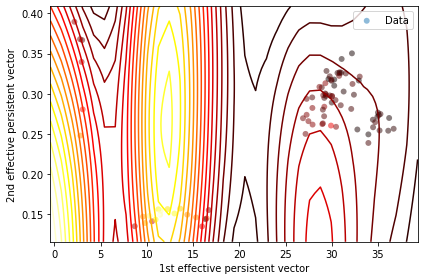

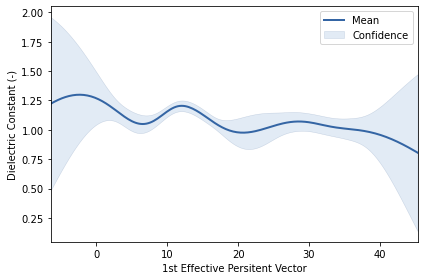

In [48]:
kernel = GPy.kern.Matern52(2, ARD=True)

model = GPy.models.GPRegression(X2_,y_, kernel)
model.optimize(messages=True, max_iters=1e5)
model.plot()
plt.xlabel("1st effective persistent vector")
plt.ylabel("2nd effective persistent vector")
plt.show()

model.plot(fixed_inputs=[(1, 0.15)], plot_data=False)
plt.xlabel("1st Effective Persitent Vector")
plt.ylabel("Dielectric Constant (-)")
plt.show()

## prediction
x_pred = np.array([np.linspace(-3, 3, 100), np.linspace(3, -3, 100)]).T
y_qua_pred = model.predict_quantiles(x_pred, quantiles=(2.5, 50, 97.5))[0]

In [79]:
kernel = GPy.kern.Matern52(2, ARD=True)

model = GPy.models.GPRegression(X2_,y_, kernel)
model.optimize(messages=True, max_iters=1e5)
model.plot()
plt.xlabel("1st effective persistent vector")
plt.ylabel("2nd effective persistent vector")
plt.show()

model.plot(fixed_inputs=[(1, 20)], plot_data=False)
plt.xlabel("2nd Effective Persitent Vector")
plt.ylabel("Dielectric Constant (-)")
plt.show()

## prediction
x_pred = np.array([np.linspace(-3, 3, 100), np.linspace(3, -3, 100)]).T
y_qua_pred = model.predict_quantiles(x_pred, quantiles=(2.5, 50, 97.5))[0]

pd_inverse = pd_vects_std[:,(206,313,188,394,118,610,401,453,519,204,206,313,368,421,961,165,102,1376,317,207,587,88)]
#pd_inverse = pdvects2[:,(206,313)]
pd_inverse

array([[-0.23478241, -0.20448669, -0.21338917, ..., -0.22559139,
        -0.19716745, -0.21820237],
       [-0.18842521, -0.21659413, -0.19060329, ..., -0.19315149,
        -0.26258353, -0.19832735],
       [-0.17835907, -0.17119124, -0.17833725, ..., -0.1938417 ,
        -0.17847714, -0.18498565],
       ...,
       [ 0.0457449 ,  0.04976951,  0.05378053, ...,  0.05722242,
         0.05515173,  0.07373338],
       [ 0.04203632,  0.03463521,  0.05365276, ...,  0.05377137,
        -0.02895466,  0.05709063],
       [ 0.0449502 ,  0.05582323,  0.05948764, ...,  0.05497924,
         0.10187751,  0.05028224]])

In [119]:
list_pd=np.array[188,118,401,519,206,368,961,102,317,317,317,587,859,297,420,288,421,63,103,317,62,340,117,425,183,289,340,313,134,289,693,101,269,188,366,289,169,204,224,103,165,397,205,224,591,662,366,367,188,368,297,266,225,223,983,166,247,510,267,295,292,133,366,348,366,1174,693,313,295,399,294,168,517,220,589,165,185,134,315,88,243,835,225,462,133,246,118,88,312,364,188,115,188,244,148,510,224,86,169,101,394,610,453,204,313,421,165,1376,207,207,184,88,165,88,132,817,88,392,186,479,270,205,366,391,101,717,418,1174,100,149,392,167,859,243,63,662,494,575,165,421,221,337,225,320,149,593,943,510,247,167,366,244,693,369,134,618,524,268,1273,270,738,292,132,26,62,392,1174,224,147,169,349,147,610,53,315,292,364,226,859,246,250,433,575,134,165,103,401,43,203,63,204,185,208,205,511,584,88,62,493,296]


TypeError: 'builtin_function_or_method' object is not subscriptable

In [118]:
#indices3 = pdvects_all2[:,[188,118, 401, 519, 206, 368, 961, 102, 317, 587]]
indices3 = pdvects_all2[:,[188,118,401,519,206,368,961,102,317,317,317,587,859,297,420,288,421,63,103,317,62,340,117,425,183,289,340,313,134,289,693,101,269,188,366,289,169,204,224,103,165,397,205,224,591,662,366,367,188, 368,297,266,225,223,983,166,247,510,267,295,292,133,366,348,366,1174,693,313,295,399,294,168,517,220,589,165,185,134,315,88,243,835,225,462,133,246,118,88,312,364,188,115,188,244,148,510,224,86,169,101,394,610,453,204,313,421,165,1376,207,207,184,88,165,88,132,817,88,392,186,479,270,205,366,391,101,717,418,1174,100,149,392,167,859,243,63,662,494,575,165,421,221,337,225,320,149,593,943,510,247,167,366,244,693,369,134,618,524,268,1273,270,738,292,132,26,62,392,1174,224,147,169,349,147,610,53,315,292,364,226,859,246,250,433,575,134,165,103,401,43,203,63,204,185,208,205,511,584,88,62,493,296]]
indices3

array([[-1.6529054 , -1.65392081, -1.49392841, ..., -1.37155072,
        -1.58920802, -1.70558058],
       [-1.47640677, -1.51739372, -1.60081639, ..., -1.42433595,
        -1.23522167, -1.52665008],
       [-1.38139443, -1.44689098, -0.91367941, ..., -1.39794334,
        -1.1846522 , -1.37328108],
       ...,
       [ 0.41658218,  0.5353749 ,  0.56748253, ...,  0.34396935,
         0.57263716,  0.21153188],
       [ 0.41559246,  0.44567903,  0.93395558, ...,  0.58150289,
         0.67377612,  0.40579928],
       [ 0.46078931,  0.40818846,  0.70490992, ...,  0.44953981,
         0.69906086,  0.46203458]])

In [121]:
a = np.zeros_like(pdvects_all2)
a

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [123]:
#for i in  (188,118, 401, 519, 206, 368, 961, 102, 317):
for i in  (188,118,401,519,206,368,961,102,317,317,317,587,859,297,420,288,421,63,103,317,62,340,117,425,183,289,340,313,134,289,693,101,269,188,366,289,169,204,224,103,165,397,205,224,591,662,366,367,188, 368,297,266,225,223,983,166,247,510,267,295,292,133,366,348,366,1174,693,313,295,399,294,168,517,220,589,165,185,134,315,88,243,835,225,462,133,246,118,88,312,364,188,115,188,244,148,510,224,86,169,101,394,610,453,204,313,421,165,1376,207,207,184,88,165,88,132,817,88,392,186,479,270,205,366,391,101,717,418,1174,100,149,392,167,859,243,63,662,494,575,165,421,221,337,225,320,149,593,943,510,247,167,366,244,693,369,134,618,524,268,1273,270,738,292,132,26,62,392,1174,224,147,169,349,147,610,53,315,292,364,226,859,246,250,433,575,134,165,103,401,43,203,63,204,185,208,205,511,584,88,62,493,296):
    a[:,i]=pdvects_all2[:,i]
#a[0,indices3]=pdvects_all3
a

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [124]:
_a = np.sum(abs(a), axis=0)
_a

array([0., 0., 0., ..., 0., 0., 0.])

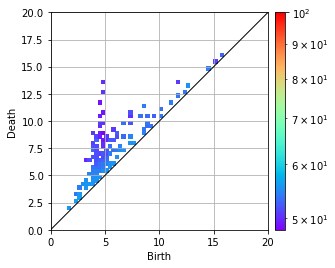

In [128]:
mesh = hc.PIVectorizerMesh((0, 20), 64, sigma=0.002, weight=("atan", 0.01, 3))
a_pd = mesh.histogram_from_vector(_a).plot(colorbar={"type": "log","max":100})

PDベクトル変数を増やす

In [170]:
pdvects_extract2_ = pdvects2.iloc[:,[88,266, 116#,  449,  220, 1032,  118,  651, 1191,  393,  799,
                                     #762, 1097,   89,  186, 1152,  313,  777, 1054,  374, 1451,  392, 481,  398,  755,   52,  658,  722,  927,  312,  620,  422, 1013, 893
                                    ]]
X3_ = np.array(pdvects_extract2_)
X3_

array([[ 1.88720328, 12.4777587 ,  4.44112264],
       [ 2.59276829, 18.60718403,  5.42986979],
       [ 3.06640016, 17.95045988,  6.06431589],
       [ 2.99559952, 18.82609207,  6.29502355],
       [ 3.3203059 , 24.5177013 ,  6.5504499 ],
       [ 3.35692692, 24.29879326,  6.59988726],
       [ 3.47167279, 23.42316107,  6.95418832],
       [ 3.56932885, 26.48787373,  7.06954216],
       [ 3.93553906, 34.80637953,  7.19313555],
       [ 3.87694542, 31.30385077,  7.39088498],
       [ 3.90380084, 31.08494273,  7.93469592],
       [ 2.19970266, 13.35339089,  4.90253798],
       [ 2.06542558, 15.76137941,  4.9190171 ],
       [ 2.18261285, 12.25885065,  5.08380829],
       [ 2.4438428 , 16.85591965,  5.20740168],
       [ 2.48778803, 19.92063231,  4.89429842],
       [ 2.4438428 , 18.60718403,  5.42163023],
       [ 2.60009249, 18.38827598,  5.07556873],
       [ 2.57079567, 16.6370116 ,  5.90776425],
       [13.82321472, 72.67747173, 22.20561319],
       [13.69870325, 61.29425326, 21.851

In [ ]:
a_pd = mesh.histogram_from_vector(_a).plot(colorbar={"type": "log","max":100000})

In [39]:
kernel = GPy.kern.Matern52(2, ARD=True)

model = GPy.models.GPRegression(X2_,y_, kernel)
model.optimize(messages=True, max_iters=1e5)
model.plot()
plt.show()

model.plot(fixed_inputs=[(0, 10)], plot_data=False)
plt.xlabel("Most Effective Persitent Vector")
plt.ylabel("Dielectric Constant (-)")
plt.show()

## prediction
x_pred = np.array([np.linspace(-3, 3, 100), np.linspace(3, -3, 100)]).T
y_qua_pred = model.predict_quantiles(x_pred, quantiles=(2.5, 50, 97.5))[0]


NameError: name 'GPy' is not defined

In [89]:
y

array([1.05408362, 1.18867284, 1.17745153, 1.19282481, 1.17063452,
       1.1448491 , 1.147685  , 1.11858476, 1.07697557, 1.04903497,
       1.01344656, 1.07556949, 1.16033186, 1.15113035, 1.19080523,
       1.22560828, 1.21596193, 1.24927047, 1.22827692, 1.0153738 ,
       1.01724022, 1.0061696 , 1.01205201, 1.01087698, 1.01864735,
       1.01215573, 1.00640363, 1.0184576 , 1.01681518, 1.00675374,
       1.03222667])

In [38]:
y_ = np.array(y).reshape(-1,1)
y_

array([[1.05408362],
       [1.18867284],
       [1.17745153],
       [1.19282481],
       [1.17063452],
       [1.1448491 ],
       [1.147685  ],
       [1.11858476],
       [1.07697557],
       [1.04903497],
       [1.01344656],
       [1.07556949],
       [1.16033186],
       [1.15113035],
       [1.19080523],
       [1.22560828],
       [1.21596193],
       [1.24927047],
       [1.22827692],
       [1.0153738 ],
       [1.01724022],
       [1.0061696 ],
       [1.01205201],
       [1.01087698],
       [1.01864735],
       [1.01215573],
       [1.00640363],
       [1.0184576 ],
       [1.01681518],
       [1.00675374],
       [1.03222667],
       [1.02554789],
       [1.00601529],
       [1.01498606],
       [1.02295548],
       [1.01123896],
       [1.0080444 ],
       [1.01659358],
       [1.00761531],
       [1.00233126],
       [1.0301098 ],
       [1.00760745],
       [1.01028621],
       [1.01586576],
       [1.02727596],
       [1.03002307],
       [1.01330018],
       [1.006

In [157]:
kernel = GPy.kern.Matern52(2, ARD=True)

model = GPy.models.GPRegression(X_, y_, kernel)
model.optimize(messages=True, max_iters=1e5)
model.plot()
plt.xlabel("Pressure (atm)")
plt.ylabel("Temparature (K)")
#plt.savefig("../results/PGy1.png")
plt.show()

model.plot(fixed_inputs=[(0, 750)], plot_data=False)
plt.xlabel("Temparature (K) @ 750atm")
plt.ylabel("Dielectric Constant (-)")
#plt.savefig("../results/PGy2.png")
plt.show()

## prediction
x_pred = np.array([np.linspace(-3, 3, 100), np.linspace(3, -3, 100)]).T
y_qua_pred = model.predict_quantiles(x_pred, quantiles=(2.5, 50, 97.5))[0]

 /home/user/.local/lib/python3.6/site-packages/GPy/core/gp.py:87: UserWarning:Your kernel has a different input dimension 2 then the given X dimension 1. Be very sure this is what you want and you have not forgotten to set the right input dimenion in your kernel


AssertionError: At least 2 dimensional X needed, X.shape=(31, 1)